# Detection Statistique (Clustering DBSCAN)

### Aperçu
Ce notebook réalise une détection statistique d'ombrage sur un parc PV en plusieurs étapes :

- Charger et prétraiter les données (clear-sky)
- Calculer une référence robuste par corrélation et correction (référence corrigée)
- Détecter les anomalies individuelles par onduleur (pertes relatives)
- Extraire des profils horaires récurrents et regrouper via DBSCAN
- Produire une "Shadow Story" et visualisations pour prioriser les investigations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
df_clear = pd.read_csv("farm_array_elec_clearsky.csv")
print(df_clear.columns.tolist())
print(df_clear.head())

['Unnamed: 0', 'measured_on', 'inv_01_dc_current', 'inv_01_dc_voltage', 'inv_01_ac_current', 'inv_01_ac_voltage', 'inv_01_ac_power', 'inv_02_dc_current', 'inv_02_dc_voltage', 'inv_02_ac_current', 'inv_02_ac_voltage', 'inv_02_ac_power', 'inv_03_dc_current', 'inv_03_dc_voltage', 'inv_03_ac_current', 'inv_03_ac_voltage', 'inv_03_ac_power', 'inv_05_dc_current', 'inv_05_ac_current', 'inv_05_ac_voltage', 'inv_05_ac_power', 'inv_06_dc_current', 'inv_06_dc_voltage', 'inv_06_ac_current', 'inv_06_ac_voltage', 'inv_06_ac_power', 'inv_07_dc_current', 'inv_07_dc_voltage', 'inv_07_ac_current', 'inv_07_ac_voltage', 'inv_07_ac_power', 'inv_08_dc_current', 'inv_08_dc_voltage', 'inv_08_ac_current', 'inv_08_ac_voltage', 'inv_08_ac_power', 'inv_09_dc_current', 'inv_09_dc_voltage', 'inv_09_ac_current', 'inv_09_ac_voltage', 'inv_09_ac_power', 'inv_10_dc_current', 'inv_10_dc_voltage', 'inv_10_ac_current', 'inv_10_ac_voltage', 'inv_10_ac_power', 'inv_11_dc_current', 'inv_11_dc_voltage', 'inv_11_ac_current', '

## Configuration

Cette cellule définit les paramètres modifiables du pipeline :

- `ANOMALY_THRESHOLD` : seuil minimal de perte relative pour considérer un point comme anomalie (ex. 15% = 0.15)
- `MIN_DURATION` : durée minimale (en minutes) pour qu'une séquence d'anomalies soit retenue (évite les faux positifs courts)
- `RECURRENCE_THRESHOLD` : proportion de jours requise pour qualifier un motif comme récurrent
- `MIN_POWER_THRESHOLD` : seuil de puissance minimal pour exclure la nuit / faible production

Ajustez ces paramètres selon la sensibilité souhaitée et la qualité des données (ex. baisser `ANOMALY_THRESHOLD` pour détecter pertes plus faibles).

In [3]:
# Paramètres de détection
ANOMALY_THRESHOLD = 0.10  # 15% d'écart minimum vs référence
MIN_DURATION = 15  # Minutes consécutives minimum
RECURRENCE_THRESHOLD = 0.60  # 60% de jours avec anomalie = motif récurrent
MIN_POWER_THRESHOLD = 50  # W - Seuil minimum pour analyse (évite nuit)

# Paramètres DBSCAN
DBSCAN_EPS_DAYS = 12  # Tolérance temporelle (jours)
DBSCAN_MIN_SAMPLES = 6  # Minimum de jours pour former un cluster
DBSCAN_EPS_HOURS = 0.5  # Tolérance horaire (heures)

# Paramètres saisonniers
SEASONS = {
    'Winter': [12, 1, 2],
    'Spring': [3, 4, 5],
    'Summer': [6, 7, 8],
    'Autumn': [9, 10, 11]
}

print("🔍 Chargement des données prétraitées...")

🔍 Chargement des données prétraitées...


## Chargement et préparation des données

In [4]:
df_clear = pd.read_csv("farm_array_elec_clearsky.csv")

# Renommage de la colonne temporelle
if 'measured_on' in df_clear.columns:
    df_clear['timestamp'] = pd.to_datetime(df_clear['measured_on'])
elif 'timestamp' not in df_clear.columns:
    raise ValueError("Aucune colonne temporelle trouvée (measured_on ou timestamp)")

df_clear = df_clear.sort_values('timestamp').reset_index(drop=True)

# Détection des onduleurs (colonnes inv_XX_ac_power)
power_cols = [c for c in df_clear.columns if c.endswith('_ac_power') and c.startswith('inv_')]
inverter_ids = [c.replace('_ac_power', '') for c in power_cols]

print(f"✓ {len(df_clear)} lignes chargées")
print(f"✓ {len(power_cols)} onduleurs détectés: {inverter_ids[:5]}{'...' if len(inverter_ids) > 5 else ''}")
print(f"✓ Période: {df_clear['timestamp'].min()} → {df_clear['timestamp'].max()}")

if len(power_cols) == 0:
    raise ValueError("❌ Aucune colonne *_ac_power trouvée!")

# Filtrage des valeurs aberrantes et nettoyage
for col in power_cols:
    df_clear[col] = pd.to_numeric(df_clear[col], errors='coerce').fillna(0)
    df_clear[col] = df_clear[col].clip(lower=0)  # Pas de puissance négative

✓ 721067 lignes chargées
✓ 23 onduleurs détectés: ['inv_01', 'inv_02', 'inv_03', 'inv_05', 'inv_06']...
✓ Période: 2017-11-01 00:00:00 → 2024-11-01 23:55:00


## Calcul du panneau de référence 

Ce bloc calcule :

- la matrice de corrélation entre onduleurs pour identifier le(s) panels les plus représentatifs
- une `reference_ensemble` (médiane des top N panels) pour une référence robuste

Raisonnement : la médiane des panels les plus corrélés atténue l'effet d'un onduleur défaillant et crée une référence stable pour mesurer les pertes relatives.

In [5]:
# Identify power columns
power_cols = [col for col in df_clear.columns if 'ac_power' in col and 'inv' in col]
print(f"📊 Found {len(power_cols)} inverter power channels")
print(f"   Analyzing clear-sky data: {len(df_clear):,} points")

# Calculate correlation matrix between all inverters
print("\n🔍 Analyzing inter-inverter correlations...")
corr_matrix = df_clear[power_cols].corr()

# Calculate average correlation for each inverter (excluding self-correlation)
corr_sums = corr_matrix.sum().sort_values(ascending=False)
corr_avg = (corr_sums - 1) / (len(power_cols) - 1)  # Subtract 1 to exclude self-correlation

# Select the inverter with highest average correlation
reference_inv = corr_sums.index[0]

print(f"\n{'='*70}")
print(f"SELECTED REFERENCE PANEL: {reference_inv}")
print(f"{'='*70}")
print(f"Average correlation: {corr_avg.iloc[0]:.4f}")
print(f"Min correlation: {corr_matrix[reference_inv].drop(reference_inv).min():.4f}")
print(f"Max correlation: {corr_matrix[reference_inv].drop(reference_inv).max():.4f}")

📊 Found 23 inverter power channels
   Analyzing clear-sky data: 721,067 points

🔍 Analyzing inter-inverter correlations...

SELECTED REFERENCE PANEL: inv_11_ac_power
Average correlation: 0.9519
Min correlation: 0.8955
Max correlation: 0.9882


In [6]:
# Select top N most correlated panels as reference candidates
N_REFERENCE_PANELS = 5  # Number of top panels to use for correction
top_panels = corr_avg.head(N_REFERENCE_PANELS).index.tolist()

print(f"🔧 Creating corrected reference using top {N_REFERENCE_PANELS} panels:")
for i, panel in enumerate(top_panels, 1):
    print(f"   {i}. {panel} (avg corr: {corr_avg.loc[panel]:.4f})")

# Create ensemble reference (median of top N panels)
df_clear['reference_ensemble'] = df_clear[top_panels].median(axis=1)

print(f"\n✅ Ensemble reference created from {N_REFERENCE_PANELS} panels")

🔧 Creating corrected reference using top 5 panels:
   1. inv_11_ac_power (avg corr: 0.9519)
   2. inv_20_ac_power (avg corr: 0.9516)
   3. inv_22_ac_power (avg corr: 0.9489)
   4. inv_12_ac_power (avg corr: 0.9488)
   5. inv_13_ac_power (avg corr: 0.9483)

✅ Ensemble reference created from 5 panels



La fonction `create_corrected_reference` détecte les points aberrants sur la référence primaire (en comparant au `ensemble_ref`) en utilisant des statistiques robustes (median, MAD) et remplace les points anormaux par la médiane.

Résultat attendu : une série `reference_corrected` avec moins de ruptures artificielles causées par un onduleur défaillant.

In [7]:
def create_corrected_reference(df, primary_ref, top_panels, sigma_threshold=3.0):
    """
    Create a corrected reference by detecting and replacing anomalies in the primary reference.
    
    Parameters:
    -----------
    df : DataFrame
        Clear-sky filtered data
    primary_ref : str
        Primary reference panel column name
    top_panels : list
        List of top N panel column names (including primary)
    sigma_threshold : float
        Threshold for anomaly detection in primary reference
    
    Returns:
    --------
    tuple: (corrected_reference_series, correction_info_dict)
    """
    # Start with primary reference
    ref_corrected = df[primary_ref].copy()
    
    # Calculate ensemble reference (median of top N)
    ensemble_ref = df[top_panels].median(axis=1)
    
    # Detect anomalies in primary reference by comparing to ensemble
    # Calculate the ratio: primary / ensemble
    ratio = ref_corrected / ensemble_ref
    ratio = ratio.replace([np.inf, -np.inf], np.nan)
    
    # Use robust statistics for anomaly detection
    median_ratio = ratio.median()
    mad = np.median(np.abs(ratio - median_ratio))
    std_estimate = 1.4826 * mad
    
    # Define thresholds (both upper and lower bounds)
    lower_threshold = median_ratio - sigma_threshold * std_estimate
    upper_threshold = median_ratio + sigma_threshold * std_estimate
    
    # Identify anomalies (deviations from expected behavior)
    anomalies = (ratio < lower_threshold) | (ratio > upper_threshold)
    n_anomalies = anomalies.sum()
    
    # Replace anomalous values with ensemble median
    ref_corrected[anomalies] = ensemble_ref[anomalies]
    
    correction_info = {
        'n_corrections': n_anomalies,
        'correction_pct': n_anomalies / len(df) * 100,
        'median_ratio': median_ratio,
        'lower_threshold': lower_threshold,
        'upper_threshold': upper_threshold,
        'anomaly_mask': anomalies
    }
    
    return ref_corrected, correction_info

# Create corrected reference
reference_corrected, correction_info = create_corrected_reference(
    df_clear, 
    reference_inv, 
    top_panels,
    sigma_threshold=3.0
)

df_clear['reference_corrected'] = reference_corrected

print(f"\n📊 Reference Correction Statistics:")
print(f"   Anomalies detected: {correction_info['n_corrections']:,} points ({correction_info['correction_pct']:.3f}%)")
print(f"   Median ratio (primary/ensemble): {correction_info['median_ratio']:.4f}")
print(f"   Threshold range: [{correction_info['lower_threshold']:.4f}, {correction_info['upper_threshold']:.4f}]")

if correction_info['n_corrections'] > 0:
    print(f"   ✅ Corrected reference created with {correction_info['n_corrections']} points adjusted")
else:
    print(f"   ✅ Primary reference is clean - no corrections needed")


📊 Reference Correction Statistics:
   Anomalies detected: 0 points (0.000%)
   Median ratio (primary/ensemble): 0.9997
   Threshold range: [nan, nan]
   ✅ Primary reference is clean - no corrections needed


## Etape 1 : Détection des outliers par ondulateurs 

Cette étape calcule une perte relative (`loss_pct`) pour chaque onduleur par rapport à `reference_corrected` et identifie les périodes où la perte dépasse `ANOMALY_THRESHOLD` pendant au moins `MIN_DURATION` minutes.

Points importants :
- On ignore les périodes où la référence est faible (nuit) via `MIN_POWER_THRESHOLD_ADJUSTED`.
- Les anomalies courtes sont filtrées par `MIN_DURATION` pour limiter le bruit.
- Les résultats sont stockés dans `df_anomalies` (période, durée, perte moyenne/max).

Interprétation rapide des sorties :
- Un grand nombre d'anomalies courtes → bruit/nuages transitoires
- Anomalies longues et récurrentes → ombrage structurel ou problème matériel

In [8]:
MIN_POWER_THRESHOLD_ADJUSTED = float(MIN_POWER_THRESHOLD / 1000)

In [9]:
# Détection des anomalies
print(f"\n🔍 Détection des anomalies (seuil: {ANOMALY_THRESHOLD:.1%})...")

# Préparation du DataFrame pour l'analyse
df_ratios = df_clear[['timestamp', 'hour', 'date', 'reference_corrected']].copy()

# Masque pour filtrer les périodes de production significative
mask_daylight = df_clear['reference_corrected'] > MIN_POWER_THRESHOLD_ADJUSTED

print(f"\n📊 Périodes analysées:")
print(f"  Points valides (production): {mask_daylight.sum():,} / {len(df_clear):,} ({mask_daylight.sum()/len(df_clear)*100:.1f}%)")

if mask_daylight.sum() == 0:
    raise ValueError("❌ Aucune période de production détectée. Vérifiez MIN_POWER_THRESHOLD_ADJUSTED ou les données.")

# Détection des anomalies pour chaque onduleur
anomalies = []
print(f"\n🔎 Analyse onduleur par onduleur:")

for inv_id, power_col in zip(inverter_ids, power_cols):
    
    # Calcul de la perte relative par rapport à reference_corrected
    # loss_pct = (référence - réel) / référence
    # Exemple: si référence=100W et onduleur=70W → loss_pct = 30% = 0.30
    loss_pct = np.where(
        df_clear['reference_corrected'] > MIN_POWER_THRESHOLD_ADJUSTED,
        (df_clear['reference_corrected'] - df_clear[power_col]) / df_clear['reference_corrected'],
        0.0
    )
    loss_pct = np.clip(loss_pct, 0, 1.0)  # Entre 0% et 100%
    
    # Stockage pour analyse ultérieure
    df_ratios[f'loss_{inv_id}'] = loss_pct
    
    # Masque d'anomalie: perte > seuil ET production significative
    mask_anomaly = (loss_pct > ANOMALY_THRESHOLD) & mask_daylight
    
    # Statistiques de cet onduleur
    if mask_daylight.sum() > 0:
        avg_loss_daylight = loss_pct[mask_daylight].mean()
        max_loss_daylight = loss_pct[mask_daylight].max()
        
        if mask_anomaly.sum() > 0:
            avg_loss_anomaly = loss_pct[mask_anomaly].mean()
            print(f"  {inv_id}: {mask_anomaly.sum():>6} anomalies | "
                  f"Perte moy totale: {avg_loss_daylight:>5.1%} | "
                  f"Perte moy anomalies: {avg_loss_anomaly:>5.1%} | "
                  f"Perte max: {max_loss_daylight:>5.1%}")
    
    # Regroupement en séquences continues (durée minimale)
    df_temp = pd.DataFrame({
        'timestamp': df_clear['timestamp'],
        'anomaly': mask_anomaly,
        'loss_pct': loss_pct
    })
    
    df_temp['anomaly_group'] = (df_temp['anomaly'] != df_temp['anomaly'].shift()).cumsum()
    
    for group_id, group in df_temp[df_temp['anomaly']].groupby('anomaly_group'):
        duration_minutes = len(group) * 5  # Intervalle de 5 minutes
        
        if duration_minutes >= MIN_DURATION:
            anomalies.append({
                'inverter_id': inv_id,
                'start_time': group['timestamp'].iloc[0],
                'end_time': group['timestamp'].iloc[-1],
                'duration_min': duration_minutes,
                'avg_deviation': group['loss_pct'].mean(),
                'max_deviation': group['loss_pct'].max()
            })

# Création du DataFrame des anomalies
df_anomalies = pd.DataFrame(anomalies)

print(f"\n{'='*70}")
if len(df_anomalies) == 0:
    print("⚠️  Aucune anomalie détectée avec les seuils actuels")
    print(f"💡 Suggestions:")
    print(f"  - Réduire ANOMALY_THRESHOLD (actuellement {ANOMALY_THRESHOLD:.1%})")
    print(f"  - Réduire MIN_DURATION (actuellement {MIN_DURATION} min)")
    print(f"  - Vérifier que reference_corrected est correctement calculée")
else:
    print(f"✅ RÉSULTATS DÉTECTION:")
    print(f"  • {len(df_anomalies):,} périodes d'anomalie détectées")
    print(f"  • {df_anomalies['inverter_id'].nunique()} onduleurs concernés")
    print(f"  • Durée totale: {df_anomalies['duration_min'].sum():,.0f} minutes")
    print(f"  • Perte moyenne: {df_anomalies['avg_deviation'].mean():.1%}")
    print(f"  • Perte maximale: {df_anomalies['max_deviation'].max():.1%}")
    
    print(f"\n📊 Top 5 onduleurs les plus affectés:")
    top_affected = df_anomalies.groupby('inverter_id').agg({
        'duration_min': 'sum',
        'avg_deviation': 'mean'
    }).sort_values('duration_min', ascending=False).head(5)
    
    for inv, row in top_affected.iterrows():
        print(f"  {inv}: {row['duration_min']:>8,.0f} min | Perte moy: {row['avg_deviation']:>5.1%}")



🔍 Détection des anomalies (seuil: 10.0%)...

📊 Périodes analysées:
  Points valides (production): 337,559 / 721,067 (46.8%)

🔎 Analyse onduleur par onduleur:
  inv_01:  83113 anomalies | Perte moy totale: 10.2% | Perte moy anomalies: 39.6% | Perte max: 100.0%
  inv_02: 124513 anomalies | Perte moy totale: 17.0% | Perte moy anomalies: 44.2% | Perte max: 100.0%
  inv_03:  80659 anomalies | Perte moy totale:  8.8% | Perte moy anomalies: 31.8% | Perte max: 100.0%
  inv_05:  71625 anomalies | Perte moy totale:  8.7% | Perte moy anomalies: 37.2% | Perte max: 100.0%
  inv_06:  94499 anomalies | Perte moy totale: 14.3% | Perte moy anomalies: 48.4% | Perte max: 100.0%
  inv_07:  75568 anomalies | Perte moy totale: 14.4% | Perte moy anomalies: 61.5% | Perte max: 100.0%
  inv_08:  50086 anomalies | Perte moy totale:  7.5% | Perte moy anomalies: 43.2% | Perte max: 100.0%
  inv_09:  32836 anomalies | Perte moy totale:  3.2% | Perte moy anomalies: 30.2% | Perte max: 100.0%
  inv_10:  44512 anomalie

- `df_anomalies` contient les périodes où un onduleur est significativement en dessous du comportement attendu (seuil `ANOMALY_THRESHOLD`, durée ≥ `MIN_DURATION`).
- Un grand nombre d'anomalies courtes peut indiquer du bruit (nuages transitoires, capteurs, erreurs de données).
- Des anomalies longues et récurrentes suggèrent un ombrage récurrent ou un problème matériel.


## Etape 2 : Profils horaires (shadox profiles)

À partir de `df_anomalies`, cette étape agrège par jour/heure/saison pour détecter des motifs récurrents (taux de récurrence ≥ `RECURRENCE_THRESHOLD`).

- `df_profiles` contient les profils horaires récurrents par onduleur et saison.
- `avg_loss_pct` quantifie l'impact énergétique moyen du profil.

Utilisation : ces profils permettent d'identifier à quelles heures et saisons un onduleur est systématiquement affecté (ex. ombre matinale récurrente).

In [10]:
# Initialisation AVANT la condition
df_profiles = pd.DataFrame()
profiles = []

if len(df_anomalies) > 0:
    # Extraction des caractéristiques temporelles
    df_anomalies['date'] = df_anomalies['start_time'].dt.date
    df_anomalies['hour'] = df_anomalies['start_time'].dt.hour
    df_anomalies['minute'] = df_anomalies['start_time'].dt.minute
    df_anomalies['time_decimal'] = df_anomalies['hour'] + df_anomalies['minute']/60
    df_anomalies['month'] = df_anomalies['start_time'].dt.month
    df_anomalies['day_of_year'] = df_anomalies['start_time'].dt.dayofyear
    
    # Attribution des saisons
    def get_season(month):
        for season, months in SEASONS.items():
            if month in months:
                return season
        return 'Unknown'
    
    df_anomalies['season'] = df_anomalies['month'].apply(get_season)
    
    # Calcul de la récurrence
    for (inv, season), group in df_anomalies.groupby(['inverter_id', 'season']):
        total_days = group['date'].nunique()
        
        # Analyse par heure
        for hour in range(24):
            hour_mask = (group['hour'] == hour)
            if hour_mask.sum() > 0:
                recurrence_days = group[hour_mask]['date'].nunique()
                recurrence_rate = recurrence_days / total_days
                
                if recurrence_rate >= RECURRENCE_THRESHOLD:
                    profiles.append({
                        'inverter_id': inv,
                        'season': season,
                        'hour': hour,
                        'recurrence_days': recurrence_days,
                        'total_days': total_days,
                        'recurrence_rate': recurrence_rate,
                        'avg_loss_pct': group[hour_mask]['avg_deviation'].mean() * 100
                    })
    
    df_profiles = pd.DataFrame(profiles)
    print(f"✓ {len(df_profiles)} profils horaires récurrents identifiés")
    
    if len(df_profiles) > 0:
        print("\n📊 Top 5 des profils d'ombrage:")
        display = df_profiles.nlargest(5, 'avg_loss_pct')[
            ['inverter_id', 'season', 'hour', 'recurrence_rate', 'avg_loss_pct']
        ]
        for _, row in display.iterrows():
            print(f"  • {row['inverter_id']} | {row['season']} | {row['hour']:02d}h | "
                  f"Récurrence: {row['recurrence_rate']:.1%} | Perte: {row['avg_loss_pct']:.1f}%")


✓ 30 profils horaires récurrents identifiés

📊 Top 5 des profils d'ombrage:
  • inv_14 | Summer | 06h | Récurrence: 88.3% | Perte: 100.0%
  • inv_23 | Summer | 06h | Récurrence: 63.7% | Perte: 95.6%
  • inv_10 | Summer | 06h | Récurrence: 95.2% | Perte: 93.4%
  • inv_24 | Summer | 06h | Récurrence: 75.1% | Perte: 63.7%
  • inv_05 | Summer | 06h | Récurrence: 70.0% | Perte: 55.9%




**Que contient `df_profiles` ?**
- Profils horaires récurrents d'ombrage par onduleur et saison (heure, taux de récurrence, perte moyenne en %).

**Interprétation**
- Une forte `recurrence_rate` (≥ `RECURRENCE_THRESHOLD`) indique un ombrage régulier à une heure donnée (ex. arbre, obstruction structurelle).
- `avg_loss_pct` permet d'évaluer l'impact énergétique moyen du profil.


## Etape 3 : Clustering saisonier (DBSCAN)

On applique DBSCAN sur (jour_de_l'année, heure_décimale) pour regrouper les anomalies récurrentes en clusters saisonniers.

- Paramètres DBSCAN (`eps`, `min_samples`) contrôlent la sensibilité spatiale/ temporelle.
- Les clusters représentent des fenêtres horaires et périodes de l'année où un onduleur est fréquemment affecté.

Résultat : `df_clusters` récapitule les clusters détectés (période, nombre de jours, perte moyenne/max).

In [11]:
clusters_results = []

if len(df_profiles) > 0:
    for (inv, season), group_profiles in df_profiles.groupby(['inverter_id', 'season']):
        # Extraction des anomalies pour cet onduleur/saison
        mask = (df_anomalies['inverter_id'] == inv) & (df_anomalies['season'] == season)
        season_anomalies = df_anomalies[mask].copy()
        
        if len(season_anomalies) < DBSCAN_MIN_SAMPLES:
            continue
        
        # Features pour DBSCAN
        X = season_anomalies[['day_of_year', 'time_decimal']].values
        
        # Normalisation avec pondération temporelle
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Application DBSCAN
        clustering = DBSCAN(
            eps=0.5,
            min_samples=DBSCAN_MIN_SAMPLES,
            metric='euclidean'
        ).fit(X_scaled)
        
        season_anomalies['cluster'] = clustering.labels_
        
        # Analyse des clusters (exclut bruit: -1)
        for cluster_id in set(clustering.labels_):
            if cluster_id == -1:
                continue
            
            cluster_data = season_anomalies[season_anomalies['cluster'] == cluster_id]
            
            clusters_results.append({
                'inverter_id': inv,
                'season': season,
                'cluster_id': cluster_id,
                'start_date': cluster_data['start_time'].min().date(),
                'end_date': cluster_data['start_time'].max().date(),
                'n_days': cluster_data['date'].nunique(),
                'shadow_start_hour': cluster_data['time_decimal'].min(),
                'shadow_end_hour': cluster_data['time_decimal'].max(),
                'avg_loss_pct': cluster_data['avg_deviation'].mean() * 100,
                'max_loss_pct': cluster_data['max_deviation'].max() * 100
            })

df_clusters = pd.DataFrame(clusters_results)

if len(df_clusters) == 0:
    print("⚠️  Aucun cluster identifié")
    print("💡 Suggestions:")
    print(f"  - Réduire ANOMALY_THRESHOLD (actuellement {ANOMALY_THRESHOLD})")
    print(f"  - Réduire RECURRENCE_THRESHOLD (actuellement {RECURRENCE_THRESHOLD})")
    print(f"  - Réduire DBSCAN_MIN_SAMPLES (actuellement {DBSCAN_MIN_SAMPLES})")
else:
    print(f"✓ {len(df_clusters)} clusters d'ombrage identifiés")


✓ 44 clusters d'ombrage identifiés


- DBSCAN groupe des anomalies proches en jour de l'année et heure pour identifier des motifs d'ombrage cohérents (clusters), en excluant le bruit (-1).
- Un cluster indique un motif spatial/temporal répété (ex. ombre d'un mat à certaines périodes).
- `n_days`, `shadow_start_hour`, `avg_loss_pct` donnent l'importance et la fenêtre horaire du problème.


## Etape 4 : Shadow story - rapport final

Cette étape compile `df_clusters` pour produire :

- `shadow_story.csv` : résumé priorisé des ombrages (inverter, saison, fenêtre horaire, perte moyenne)
- Visualisations : heatmap de récurrence, timeline, distribution des pertes, top onduleurs affectés

In [ ]:
if len(df_clusters) > 0:
    # Formatage des heures
    def format_hour(decimal_hour):
        h = int(decimal_hour)
        m = int((decimal_hour - h) * 60)
        return f"{h:02d}h{m:02d}"
    
    df_clusters['shadow_period'] = (
        df_clusters['shadow_start_hour'].apply(format_hour) + 
        ' → ' + 
        df_clusters['shadow_end_hour'].apply(format_hour)
    )
    
    # Tri par impact
    df_shadow_story = df_clusters.sort_values('avg_loss_pct', ascending=False)
    
    # Export
    df_shadow_story.to_csv('outputs_stats/shadow_story.csv', index=False)
    print("✓ Shadow Story exportée → shadow_story.csv")
    
    print("\n🎯 SHADOW STORY - Top 10 des ombrages critiques:")
    print("="*70)
    for idx, row in df_shadow_story.head(10).iterrows():
        print(f"  {row['inverter_id']:>10} | {row['season']:>6} | {row['shadow_period']} | "
              f"{row['n_days']:3d} jours | Perte: {row['avg_loss_pct']:5.1f}%")
    
    # Visualisations
    
    print("\n📈 Génération des visualisations...")
    
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # Plot 1: Heatmap récurrence horaire
    if len(df_profiles) > 0:
        ax1 = fig.add_subplot(gs[0, :2])
        pivot = df_profiles.pivot_table(
            values='recurrence_rate',
            index='inverter_id',
            columns='hour',
            aggfunc='mean'
        )
        sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0%',
                    cbar_kws={'label': 'Taux de récurrence'}, ax=ax1)
        ax1.set_title('Récurrence Horaire des Ombrages par Onduleur', fontweight='bold')
        ax1.set_xlabel('Heure de la journée')
        ax1.set_ylabel('Onduleur')
    
    # Plot 2: Distribution des pertes
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.hist(df_clusters['avg_loss_pct'], bins=20, color='coral', edgecolor='black', alpha=0.7)
    ax2.axvline(df_clusters['avg_loss_pct'].median(), color='red', 
                linestyle='--', linewidth=2, label=f"Médiane: {df_clusters['avg_loss_pct'].median():.1f}%")
    ax2.set_title('Distribution des Pertes', fontweight='bold')
    ax2.set_xlabel('Perte moyenne (%)')
    ax2.set_ylabel('Nombre de clusters')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Plot 3: Timeline des périodes d'ombrage
    ax3 = fig.add_subplot(gs[1, :])
    colors = plt.cm.Set3(np.linspace(0, 1, len(df_clusters)))
    for idx, (i, row) in enumerate(df_clusters.iterrows()):
        start = pd.Timestamp(row['start_date'])
        end = pd.Timestamp(row['end_date'])
        ax3.barh(row['inverter_id'], (end - start).days, left=start, 
                height=0.6, color=colors[idx], alpha=0.8, edgecolor='black')
    ax3.set_title('Périodes d\'Ombrage Détectées (Timeline)', fontweight='bold')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Onduleur')
    ax3.grid(axis='x', alpha=0.3)
    
    # Plot 4: Scatter clustering (jour vs heure)
    if 'cluster' in df_anomalies.columns:
        ax4 = fig.add_subplot(gs[2, 0])
        scatter_data = df_anomalies[df_anomalies['cluster'] != -1]
        if len(scatter_data) > 0:
            scatter = ax4.scatter(scatter_data['day_of_year'], scatter_data['time_decimal'],
                                c=scatter_data['cluster'], cmap='tab10', alpha=0.6, s=15)
            ax4.set_title('Résultats DBSCAN', fontweight='bold')
            ax4.set_xlabel('Jour de l\'année')
            ax4.set_ylabel('Heure (décimale)')
            ax4.grid(alpha=0.3)
    
    # Plot 5: Répartition saisonnière
    ax5 = fig.add_subplot(gs[2, 1])
    season_counts = df_clusters['season'].value_counts()
    ax5.bar(season_counts.index, season_counts.values, color='steelblue', edgecolor='black')
    ax5.set_title('Répartition Saisonnière', fontweight='bold')
    ax5.set_xlabel('Saison')
    ax5.set_ylabel('Nombre de clusters')
    ax5.grid(axis='y', alpha=0.3)
    
    # Plot 6: Top onduleurs affectés
    ax6 = fig.add_subplot(gs[2, 2])
    inv_counts = df_clusters['inverter_id'].value_counts().head(10)
    ax6.barh(range(len(inv_counts)), inv_counts.values, color='indianred', edgecolor='black')
    ax6.set_yticks(range(len(inv_counts)))
    ax6.set_yticklabels(inv_counts.index)
    ax6.set_title('Top 10 Onduleurs Affectés', fontweight='bold')
    ax6.set_xlabel('Nombre de clusters')
    ax6.invert_yaxis()
    ax6.grid(axis='x', alpha=0.3)
    
    plt.suptitle('Détection d\'Ombrage PV - Analyse DBSCAN', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.savefig('outputs_stats/shadow_detection_results.png', dpi=150, bbox_inches='tight')
    print("✓ Visualisations sauvegardées → shadow_detection_results.png")
    plt.close()

print("\n" + "="*70)
print("✅ ANALYSE TERMINÉE")
print("="*70)

if len(df_clusters) > 0:
    total_loss = df_clusters['avg_loss_pct'].sum()
    print(f"\n📊 RÉSUMÉ:")
    print(f"  • {len(df_clusters)} périodes d'ombrage détectées")
    print(f"  • {df_clusters['inverter_id'].nunique()} onduleurs affectés")
    print(f"  • Perte moyenne par cluster: {df_clusters['avg_loss_pct'].mean():.1f}%")
    print(f"  • Perte maximale observée: {df_clusters['max_loss_pct'].max():.1f}%")
else:
    print("\n⚠️  Aucun ombrage détecté. Vérifiez les paramètres ou la qualité des données.")

✓ Shadow Story exportée → shadow_story.csv

🎯 SHADOW STORY - Top 10 des ombrages critiques:
      inv_14 | Summer | 05h49 → 08h54 | 107 jours | Perte: 100.0%
      inv_14 | Summer | 15h20 → 17h25 |   5 jours | Perte:  98.3%
      inv_10 | Summer | 06h04 → 07h40 |  59 jours | Perte:  93.6%
      inv_09 | Summer | 10h24 → 11h54 |   6 jours | Perte:  76.1%
      inv_05 | Summer | 05h55 → 20h04 | 220 jours | Perte:  73.2%
      inv_02 | Summer | 06h00 → 20h19 | 314 jours | Perte:  72.6%
      inv_23 | Summer | 06h15 → 19h30 |  91 jours | Perte:  64.6%
      inv_12 | Winter | 10h39 → 17h10 |  11 jours | Perte:  62.9%
      inv_03 | Summer | 05h49 → 20h19 | 309 jours | Perte:  59.6%
      inv_09 | Spring | 05h55 → 17h00 | 197 jours | Perte:  56.6%

📈 Génération des visualisations...
✓ Visualisations sauvegardées → shadow_detection_results.png

✅ ANALYSE TERMINÉE

📊 RÉSUMÉ:
  • 44 périodes d'ombrage détectées
  • 19 onduleurs affectés
  • Perte moyenne par cluster: 38.4%
  • Perte maximale ob

- `shadow_story.csv` synthétise les clusters détectés (onduleur, saison, période horaire, nombre de jours, pertes moyennes/max).
- Les graphiques sauvegardés (`shadow_detection_results.png`) aident à prioriser les investigations (heatmap de récurrence, timeline, distribution des pertes). 

## Génération des outputs pour la fusion

In [ ]:


print("\n" + "="*70)
print("🛠️  GÉNÉRATION DES DONNÉES POUR LA FUSION (XGBOOST)")
print("="*70)

# OUTPUT 1 : Shadow Story (Format Fusion Enrichi)
if 'df_clusters' in globals() and len(df_clusters) > 0:
    df_shadow_story_fusion = df_clusters.copy()
    
    # Calcul de la récurrence réelle
    df_shadow_story_fusion['start_date'] = pd.to_datetime(df_shadow_story_fusion['start_date'])
    df_shadow_story_fusion['end_date'] = pd.to_datetime(df_shadow_story_fusion['end_date'])
    df_shadow_story_fusion['nb_jours_total'] = (df_shadow_story_fusion['end_date'] - df_shadow_story_fusion['start_date']).dt.days + 1
    df_shadow_story_fusion['taux_recurrence'] = (df_shadow_story_fusion['n_days'] / df_shadow_story_fusion['nb_jours_total']).round(4)
    
    # Renommage pour correspondre au plan de fusion
    df_shadow_story_fusion = df_shadow_story_fusion.rename(columns={
        'season': 'saison',
        'start_date': 'date_debut',
        'end_date': 'date_fin',
        'shadow_start_hour': 'heure_debut',
        'shadow_end_hour': 'heure_fin',
        'n_days': 'nb_jours_actifs',
        'avg_loss_pct': 'intensite_moyenne_pct'
    })

    df_shadow_story_fusion.to_csv('outputs_stats/shadow_story_fusion.csv', index=False)
    print("✅ Output 1 généré : shadow_story_fusion.csv (avec taux de récurrence)")
    
# OUTPUT 2 : Série Temporelle Annotée (Version Auto-Détection)
if 'df_clear' in globals() and 'df_anomalies' in globals():
    
    # 1. Préparation des données
    base_df = df_clear.copy().reset_index()
    anom_df = df_anomalies.copy().reset_index()
    
    # 2. Identification automatique de la colonne temps
    # On cherche 'timestamp', sinon 'measured_on', sinon 'date'
    def find_time_col(df):
        for col in ['timestamp', 'measured_on', 'date', 'start_time']:
            if col in df.columns: return col
        return None

    time_col_base = find_time_col(base_df)
    time_col_anom = find_time_col(anom_df)

    if time_col_base and time_col_anom:
        # 3. Création du format Long pour la base
        target_inverters = anom_df['inverter_id'].unique()
        rows = []
        for inv in target_inverters:
            temp_df = base_df[[time_col_base]].copy()
            temp_df['inverter_id'] = inv
            rows.append(temp_df)
        
        df_ts_fusion = pd.concat(rows, ignore_index=True)
        df_ts_fusion = df_ts_fusion.rename(columns={time_col_base: 'timestamp'})
        
        # 4. Standardisation de anom_df pour le merge
        anom_df_ready = anom_df.rename(columns={time_col_anom: 'timestamp'})
        
        # Conversion forcée en datetime pour garantir le merge
        df_ts_fusion['timestamp'] = pd.to_datetime(df_ts_fusion['timestamp'])
        anom_df_ready['timestamp'] = pd.to_datetime(anom_df_ready['timestamp'])

        # 5. Initialisation et Merge
        df_ts_fusion['hour_of_day'] = df_ts_fusion['timestamp'].dt.hour
        df_ts_fusion['anomaly_detected'] = 0
        df_ts_fusion['cluster_id'] = -1
        df_ts_fusion['shadow_score'] = 0.0

        # On ne fusionne que les colonnes utiles
        cols_to_merge = ['timestamp', 'inverter_id']
        if 'cluster' in anom_df_ready.columns: cols_to_merge.append('cluster')
        if 'avg_deviation' in anom_df_ready.columns: cols_to_merge.append('avg_deviation')

        df_ts_fusion = df_ts_fusion.merge(anom_df_ready[cols_to_merge], on=['timestamp', 'inverter_id'], how='left')

        # 6. Remplissage des résultats finaux
        if 'cluster' in df_ts_fusion.columns:
            mask = df_ts_fusion['cluster'].notna()
            df_ts_fusion.loc[mask, 'anomaly_detected'] = 1
            df_ts_fusion.loc[mask, 'cluster_id'] = df_ts_fusion['cluster'].fillna(-1)
            
        if 'avg_deviation' in df_ts_fusion.columns:
            df_ts_fusion.loc[df_ts_fusion['anomaly_detected'] == 1, 'shadow_score'] = df_ts_fusion['avg_deviation'].fillna(0)

        # Export
        final_cols = ['timestamp', 'inverter_id', 'anomaly_detected', 'cluster_id', 'shadow_score', 'hour_of_day']
        df_ts_fusion[final_cols].to_csv('outputs_stats/stat_annotated_timeseries.csv', index=False)
        print("✅ Output 2 généré avec succès !")
    else:
        print("❌ Impossible de trouver une colonne temporelle valide.")

# OUTPUT 3 : Profil Horaire de Récurrence (Version complète 24h)
if 'df_profiles' in globals():
    full_24h = pd.DataFrame({'hour': range(24)})
    
    # On calcule la moyenne par heure à partir de vos profils existants
    if len(df_profiles) > 0:
        avg_profiles = df_profiles.groupby('hour')['recurrence_rate'].mean().reset_index()
        # On fusionne avec la base 24h (les heures manquantes deviendront NaN)
        hourly_profile = full_24h.merge(avg_profiles, on='hour', how='left')
        # On remplace les NaN par 0.0 (pas d'ombre détectée)
        hourly_profile['recurrence_rate'] = hourly_profile['recurrence_rate'].fillna(0.0)
    else:
        hourly_profile = full_24h
        hourly_profile['recurrence_rate'] = 0.0

    hourly_profile.to_csv('outputs_stats/stat_hourly_profile.csv', index=False)
    print("✅ Output 3 généré : stat_hourly_profile.csv (Format 24h complet)")


🛠️  GÉNÉRATION DES DONNÉES POUR LA FUSION (XGBOOST)
✅ Output 1 généré : shadow_story_fusion.csv (avec taux de récurrence)


##  Résumé global 

- **Objectif** : détecter et prioriser les motifs d'ombrage récurrents sur les onduleurs.
- **Étapes réalisées** : calcul d'une référence théorique, détection d'anomalies, construction de profils horaires récurrents, clustering DBSCAN saisonnier, compilation d'une Shadow Story et visualisations.
- **Anomalies détectées** : 26 044 sur 721k lignes ~3.6% - taux réaliste

In [41]:
# Récapitulatif chiffré

# Ce bloc affiche un résumé chiffré des résultats calculés dans le notebook.

n_anomalies = int(len(df_anomalies)) if 'df_anomalies' in globals() else 0
n_profiles = int(len(df_profiles)) if 'df_profiles' in globals() else 0
n_clusters = int(len(df_clusters)) if 'df_clusters' in globals() else 0

print('\n=== RÉCAPITULATIF CHIFFRÉ ===')
print(f'• Anomalies détectées : {n_anomalies}')
print(f'• Profils horaires récurrents : {n_profiles}')
print(f'• Clusters d\'ombrage identifiés : {n_clusters}')

if n_clusters > 0:
    print('\nTop 5 clusters (par perte moyenne) :')
    print(df_clusters.sort_values('avg_loss_pct', ascending=False)[[
        'inverter_id','season','shadow_start_hour','shadow_end_hour','n_days','avg_loss_pct'
    ]].head(5).to_string(index=False))

if 'df_shadow_story' in globals():
    print('\nshadow_story.csv est disponible → vérifiez les détails')
else:
    print('\nshadow_story.csv non généré (pas de clusters identifiés).')


=== RÉCAPITULATIF CHIFFRÉ ===
• Anomalies détectées : 46675
• Profils horaires récurrents : 30
• Clusters d'ombrage identifiés : 44

Top 5 clusters (par perte moyenne) :
inverter_id season  shadow_start_hour  shadow_end_hour  n_days  avg_loss_pct
     inv_14 Summer           5.833333         8.916667     107     99.996566
     inv_14 Summer          15.333333        17.416667       5     98.280752
     inv_10 Summer           6.083333         7.666667      59     93.605701
     inv_09 Summer          10.416667        11.916667       6     76.137561
     inv_05 Summer           5.916667        20.083333     220     73.218567

shadow_story.csv est disponible → vérifiez les détails


## Analyser csv final

ANALYSE SHADOW STORY - PVDAQ 2017-2024

📊 STATISTIQUES GÉNÉRALES:
  • Nombre total de clusters: 44
  • Onduleurs affectés: 19
  • Période couverte: 2017-11-01 → 2024-11-01
  • Durée totale cumulée: 7065 jours

💰 IMPACT ÉNERGÉTIQUE:
  • Perte moyenne: 38.4%
  • Perte médiane: 28.9%
  • Perte minimale: 13.3%
  • Perte maximale: 100.0%
  • Écart-type: 23.6%

ANALYSE PAR ONDULEUR

🎯 TOP 10 ONDULEURS LES PLUS AFFECTÉS (par perte moyenne):
             nb_clusters  total_days   avg_loss  max_loss
inverter_id                                              
inv_14                 2         112  99.138659     100.0
inv_10                 1          59  93.605701     100.0
inv_23                 1          91  64.590450     100.0
inv_02                 2         712  60.018314     100.0
inv_07                 1         449  49.997185     100.0
inv_09                 4         577  45.104588     100.0
inv_24                 1         185  42.144914     100.0
inv_03                 4        1166  38

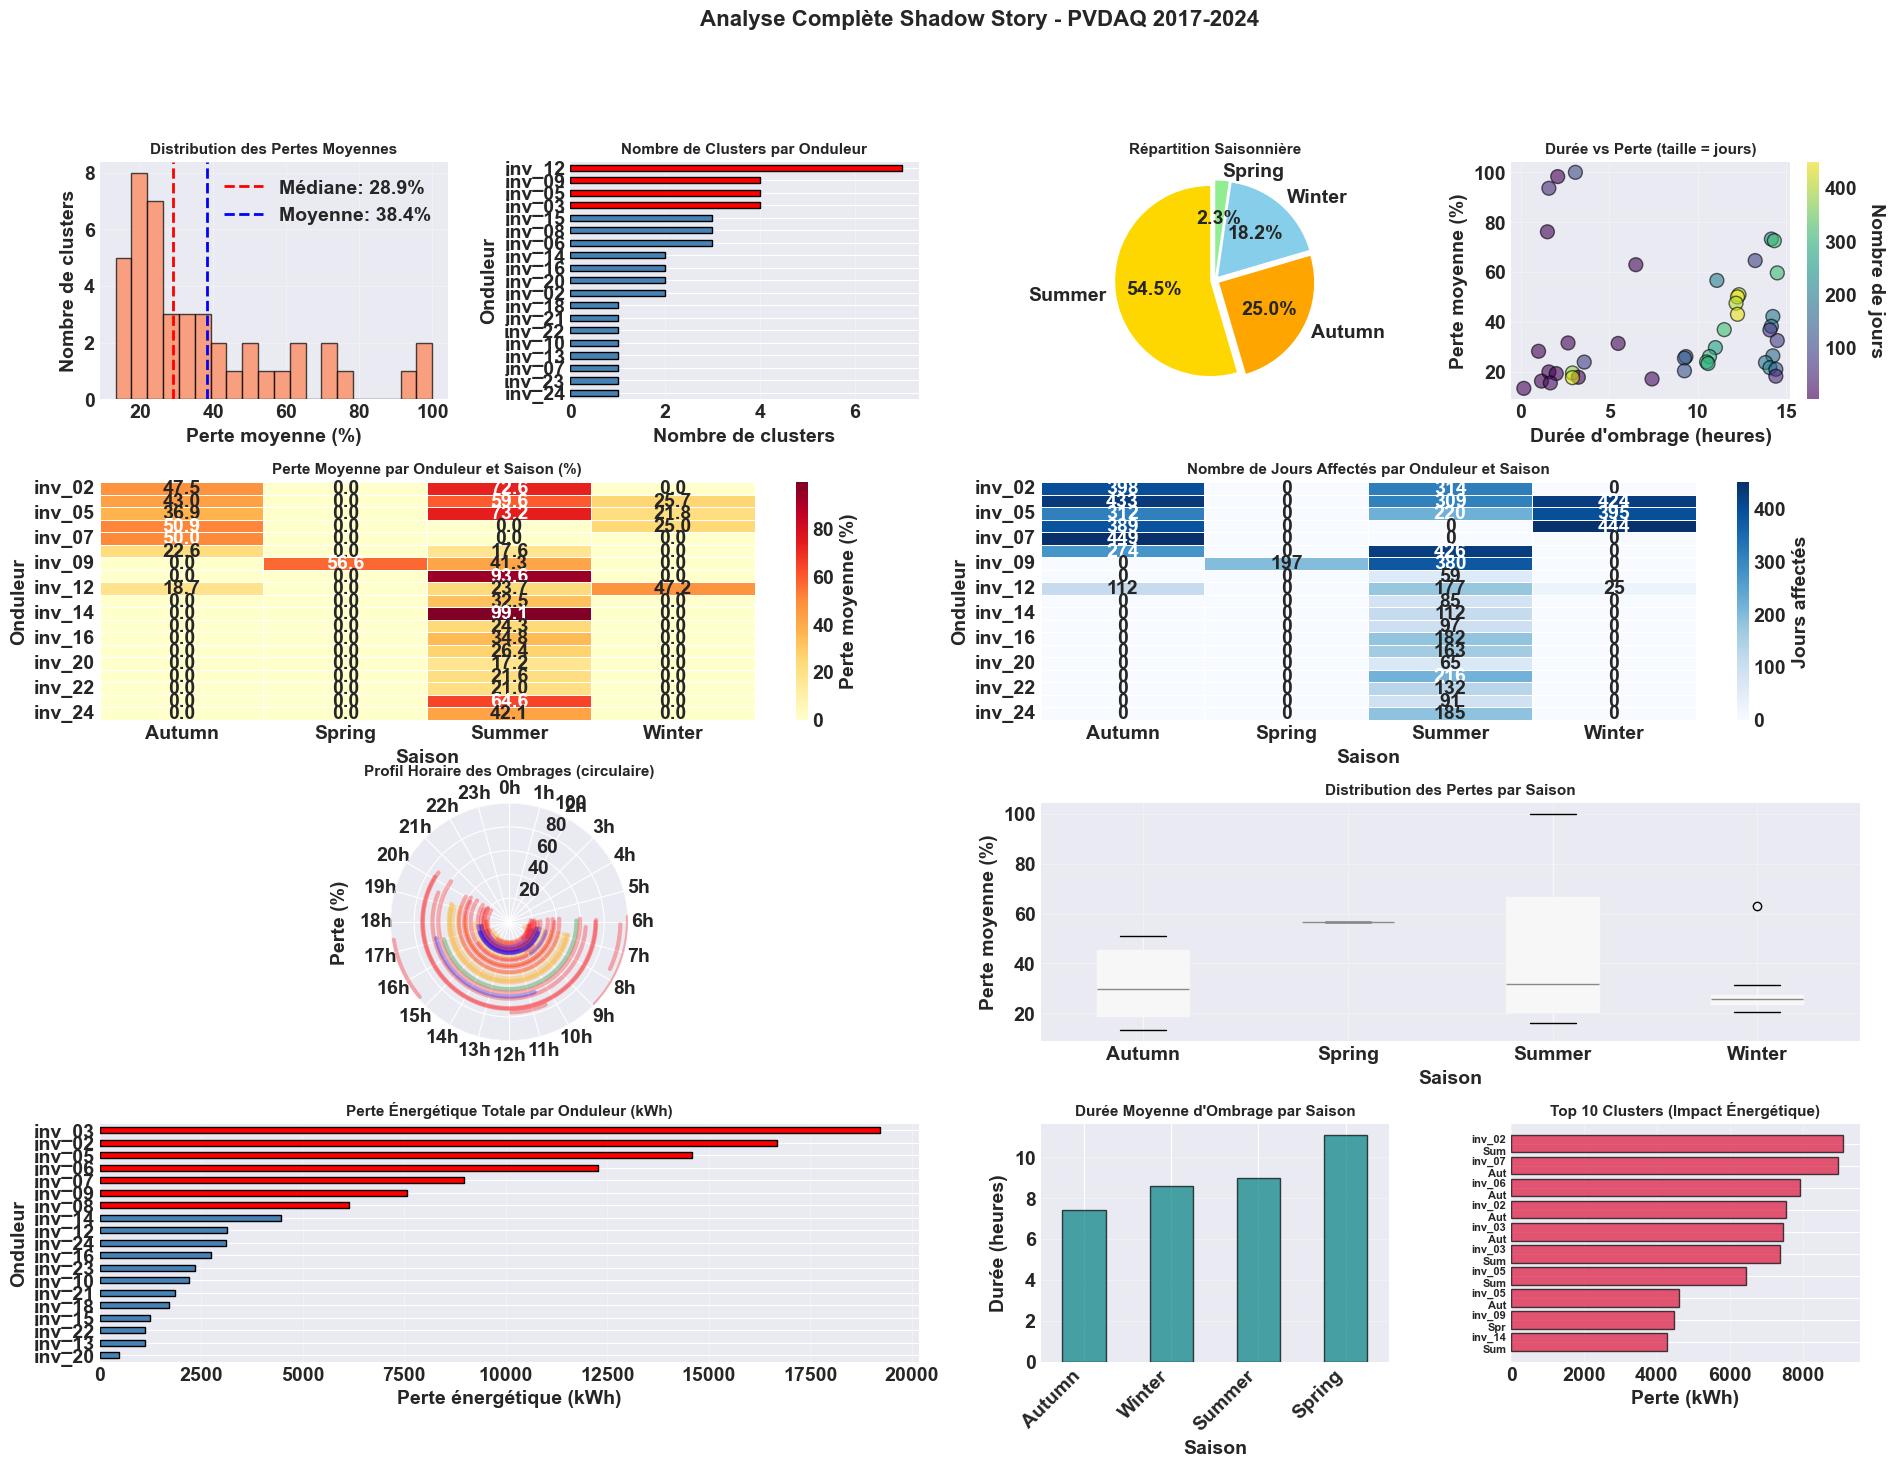

In [ ]:
"""
Analyse complète du fichier shadow_story.csv
Dataset: PVDAQ 2017-2024
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# CHARGEMENT ET ANALYSE DESCRIPTIVE
# ============================================================================

print("="*70)
print("ANALYSE SHADOW STORY - PVDAQ 2017-2024")
print("="*70)

# Chargement
df_shadow = pd.read_csv('shadow_story.csv')

print(f"\n📊 STATISTIQUES GÉNÉRALES:")
print(f"  • Nombre total de clusters: {len(df_shadow)}")
print(f"  • Onduleurs affectés: {df_shadow['inverter_id'].nunique()}")
print(f"  • Période couverte: {df_shadow['start_date'].min()} → {df_shadow['end_date'].max()}")
print(f"  • Durée totale cumulée: {df_shadow['n_days'].sum()} jours")

# Statistiques des pertes
print(f"\n💰 IMPACT ÉNERGÉTIQUE:")
print(f"  • Perte moyenne: {df_shadow['avg_loss_pct'].mean():.1f}%")
print(f"  • Perte médiane: {df_shadow['avg_loss_pct'].median():.1f}%")
print(f"  • Perte minimale: {df_shadow['avg_loss_pct'].min():.1f}%")
print(f"  • Perte maximale: {df_shadow['avg_loss_pct'].max():.1f}%")
print(f"  • Écart-type: {df_shadow['avg_loss_pct'].std():.1f}%")

# ============================================================================
# ANALYSE PAR ONDULEUR
# ============================================================================

print(f"\n{'='*70}")
print("ANALYSE PAR ONDULEUR")
print("="*70)

inv_analysis = df_shadow.groupby('inverter_id').agg({
    'cluster_id': 'count',
    'n_days': 'sum',
    'avg_loss_pct': 'mean',
    'max_loss_pct': 'max'
}).rename(columns={
    'cluster_id': 'nb_clusters',
    'n_days': 'total_days',
    'avg_loss_pct': 'avg_loss',
    'max_loss_pct': 'max_loss'
}).sort_values('avg_loss', ascending=False)

print("\n🎯 TOP 10 ONDULEURS LES PLUS AFFECTÉS (par perte moyenne):")
print(inv_analysis.head(10).to_string())

print("\n⚠️ ONDULEURS CRITIQUES (perte moyenne > 50%):")
critical_inv = inv_analysis[inv_analysis['avg_loss'] > 50]
if len(critical_inv) > 0:
    print(critical_inv.to_string())
else:
    print("  Aucun onduleur critique détecté")

# ============================================================================
# ANALYSE SAISONNIÈRE
# ============================================================================

print(f"\n{'='*70}")
print("ANALYSE SAISONNIÈRE")
print("="*70)

season_analysis = df_shadow.groupby('season').agg({
    'cluster_id': 'count',
    'n_days': 'sum',
    'avg_loss_pct': 'mean',
    'max_loss_pct': 'max'
}).rename(columns={
    'cluster_id': 'nb_clusters',
    'n_days': 'total_days',
    'avg_loss_pct': 'avg_loss',
    'max_loss_pct': 'max_loss'
})

print("\n🌍 RÉPARTITION SAISONNIÈRE:")
print(season_analysis.to_string())

# ============================================================================
# ANALYSE HORAIRE
# ============================================================================

print(f"\n{'='*70}")
print("ANALYSE TEMPORELLE")
print("="*70)

# Identification des heures de début/fin d'ombrage
df_shadow['start_hour_int'] = df_shadow['shadow_start_hour'].apply(lambda x: int(x))
df_shadow['end_hour_int'] = df_shadow['shadow_end_hour'].apply(lambda x: int(x))
df_shadow['duration_hours'] = df_shadow['shadow_end_hour'] - df_shadow['shadow_start_hour']

print("\n⏰ PATTERNS HORAIRES:")
print(f"  • Heure de début la plus fréquente: {df_shadow['start_hour_int'].mode().values[0]}h")
print(f"  • Heure de fin la plus fréquente: {df_shadow['end_hour_int'].mode().values[0]}h")
print(f"  • Durée moyenne d'ombrage: {df_shadow['duration_hours'].mean():.1f}h")
print(f"  • Durée maximale: {df_shadow['duration_hours'].max():.1f}h")

# Ombrages matinaux vs après-midi
morning_shadows = df_shadow[df_shadow['start_hour_int'] < 12]
afternoon_shadows = df_shadow[df_shadow['start_hour_int'] >= 12]

print(f"\n🌅 RÉPARTITION TEMPORELLE:")
print(f"  • Ombrages matinaux (< 12h): {len(morning_shadows)} ({len(morning_shadows)/len(df_shadow)*100:.1f}%)")
print(f"  • Ombrages après-midi (≥ 12h): {len(afternoon_shadows)} ({len(afternoon_shadows)/len(df_shadow)*100:.1f}%)")

# ============================================================================
# DÉTECTION DE PATTERNS RÉCURRENTS
# ============================================================================

print(f"\n{'='*70}")
print("PATTERNS RÉCURRENTS DÉTECTÉS")
print("="*70)

# Pattern 1: Ombrages matinaux d'été
summer_morning = df_shadow[
    (df_shadow['season'] == 'Summer') & 
    (df_shadow['start_hour_int'] <= 7)
]

if len(summer_morning) > 0:
    print(f"\n🌄 PATTERN: Ombrage matinal été (≤7h)")
    print(f"  • Nombre de clusters: {len(summer_morning)}")
    print(f"  • Onduleurs concernés: {summer_morning['inverter_id'].unique().tolist()}")
    print(f"  • Perte moyenne: {summer_morning['avg_loss_pct'].mean():.1f}%")
    print(f"  • Jours affectés: {summer_morning['n_days'].sum()}")

# Pattern 2: Ombrages longs (toute journée)
long_shadows = df_shadow[df_shadow['duration_hours'] > 10]

if len(long_shadows) > 0:
    print(f"\n📅 PATTERN: Ombrage longue durée (>10h)")
    print(f"  • Nombre de clusters: {len(long_shadows)}")
    print(f"  • Onduleurs concernés: {long_shadows['inverter_id'].unique().tolist()}")
    print(f"  • Perte moyenne: {long_shadows['avg_loss_pct'].mean():.1f}%")

# Pattern 3: Pertes catastrophiques (>80%)
severe_loss = df_shadow[df_shadow['avg_loss_pct'] > 80]

if len(severe_loss) > 0:
    print(f"\n🚨 PATTERN: Pertes sévères (>80%)")
    print(f"  • Nombre de clusters: {len(severe_loss)}")
    print(f"  • Onduleurs concernés: {severe_loss['inverter_id'].unique().tolist()}")
    print("\n  Détails:")
    for _, row in severe_loss.iterrows():
        print(f"    - {row['inverter_id']} | {row['season']} | "
              f"{row['shadow_period']} | {row['n_days']} jours | {row['avg_loss_pct']:.1f}%")

# ============================================================================
# ESTIMATION IMPACT ÉNERGÉTIQUE
# ============================================================================

print(f"\n{'='*70}")
print("ESTIMATION IMPACT ÉNERGÉTIQUE")
print("="*70)

# Hypothèses de calcul (à ajuster selon votre installation)
POWER_RATING_KW = 8.5  # Puissance nominale d'un onduleur (kW)
DAILY_PRODUCTION_KWH = 40  # Production journalière moyenne par onduleur (kWh)

# Calcul des pertes
df_shadow['energy_loss_kwh'] = (
    df_shadow['avg_loss_pct'] / 100 * 
    DAILY_PRODUCTION_KWH * 
    df_shadow['n_days']
)

total_energy_loss = df_shadow['energy_loss_kwh'].sum()
total_clusters_days = df_shadow['n_days'].sum()

print(f"\n💡 PERTES ÉNERGÉTIQUES ESTIMÉES:")
print(f"  • Perte totale: {total_energy_loss:,.0f} kWh")
print(f"  • Perte moyenne par cluster: {df_shadow['energy_loss_kwh'].mean():,.0f} kWh")
print(f"  • Équivalent jours de production perdus: {total_clusters_days:,}")

# Top 5 clusters les plus coûteux
print(f"\n💰 TOP 5 CLUSTERS LES PLUS COÛTEUX:")
top_costly = df_shadow.nlargest(5, 'energy_loss_kwh')[
    ['inverter_id', 'season', 'n_days', 'avg_loss_pct', 'energy_loss_kwh']
]
for _, row in top_costly.iterrows():
    print(f"  • {row['inverter_id']} ({row['season']}): "
          f"{row['energy_loss_kwh']:,.0f} kWh | {row['n_days']} jours | {row['avg_loss_pct']:.1f}% perte")

# ============================================================================
# GÉNÉRATION DES VISUALISATIONS
# ============================================================================

print(f"\n{'='*70}")
print("GÉNÉRATION DES VISUALISATIONS")
print("="*70)

fig = plt.figure(figsize=(22, 16))
gs = fig.add_gridspec(4, 4, hspace=0.35, wspace=0.35)

# ============================================================================
# PLOT 1: Distribution des pertes moyennes
# ============================================================================
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df_shadow['avg_loss_pct'], bins=20, color='coral', edgecolor='black', alpha=0.7)
ax1.axvline(df_shadow['avg_loss_pct'].median(), color='red', linestyle='--', 
            linewidth=2, label=f"Médiane: {df_shadow['avg_loss_pct'].median():.1f}%")
ax1.axvline(df_shadow['avg_loss_pct'].mean(), color='blue', linestyle='--', 
            linewidth=2, label=f"Moyenne: {df_shadow['avg_loss_pct'].mean():.1f}%")
ax1.set_title('Distribution des Pertes Moyennes', fontweight='bold', fontsize=11)
ax1.set_xlabel('Perte moyenne (%)')
ax1.set_ylabel('Nombre de clusters')
ax1.legend()
ax1.grid(alpha=0.3)

# ============================================================================
# PLOT 2: Nombre de clusters par onduleur
# ============================================================================
ax2 = fig.add_subplot(gs[0, 1])
inv_counts = df_shadow['inverter_id'].value_counts().sort_values(ascending=True)
colors = ['red' if x > 3 else 'steelblue' for x in inv_counts.values]
inv_counts.plot(kind='barh', ax=ax2, color=colors, edgecolor='black')
ax2.set_title('Nombre de Clusters par Onduleur', fontweight='bold', fontsize=11)
ax2.set_xlabel('Nombre de clusters')
ax2.set_ylabel('Onduleur')
ax2.grid(axis='x', alpha=0.3)

# ============================================================================
# PLOT 3: Répartition saisonnière
# ============================================================================
ax3 = fig.add_subplot(gs[0, 2])
season_counts = df_shadow['season'].value_counts()
colors_season = {'Winter': 'skyblue', 'Spring': 'lightgreen', 
                 'Summer': 'gold', 'Autumn': 'orange'}
ax3.pie(season_counts.values, labels=season_counts.index, autopct='%1.1f%%',
        colors=[colors_season.get(s, 'gray') for s in season_counts.index],
        startangle=90, explode=[0.05]*len(season_counts))
ax3.set_title('Répartition Saisonnière', fontweight='bold', fontsize=11)

# ============================================================================
# PLOT 4: Durée des ombrages
# ============================================================================
ax4 = fig.add_subplot(gs[0, 3])
ax4.scatter(df_shadow['duration_hours'], df_shadow['avg_loss_pct'], 
           c=df_shadow['n_days'], cmap='viridis', s=100, alpha=0.6, edgecolors='black')
cbar = plt.colorbar(ax4.collections[0], ax=ax4)
cbar.set_label('Nombre de jours', rotation=270, labelpad=20)
ax4.set_title('Durée vs Perte (taille = jours)', fontweight='bold', fontsize=11)
ax4.set_xlabel('Durée d\'ombrage (heures)')
ax4.set_ylabel('Perte moyenne (%)')
ax4.grid(alpha=0.3)

# ============================================================================
# PLOT 5: Heatmap pertes par onduleur et saison
# ============================================================================
ax5 = fig.add_subplot(gs[1, :2])
pivot_loss = df_shadow.pivot_table(
    values='avg_loss_pct', 
    index='inverter_id', 
    columns='season', 
    aggfunc='mean',
    fill_value=0
)
sns.heatmap(pivot_loss, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Perte moyenne (%)'}, ax=ax5, linewidths=0.5)
ax5.set_title('Perte Moyenne par Onduleur et Saison (%)', fontweight='bold', fontsize=11)
ax5.set_xlabel('Saison')
ax5.set_ylabel('Onduleur')

# ============================================================================
# PLOT 6: Heatmap nombre de jours affectés
# ============================================================================
ax6 = fig.add_subplot(gs[1, 2:])
pivot_days = df_shadow.pivot_table(
    values='n_days', 
    index='inverter_id', 
    columns='season', 
    aggfunc='sum',
    fill_value=0
)
sns.heatmap(pivot_days, annot=True, fmt='.0f', cmap='Blues', 
            cbar_kws={'label': 'Jours affectés'}, ax=ax6, linewidths=0.5)
ax6.set_title('Nombre de Jours Affectés par Onduleur et Saison', fontweight='bold', fontsize=11)
ax6.set_xlabel('Saison')
ax6.set_ylabel('Onduleur')

# ============================================================================
# PLOT 7: Timeline des ombrages (circulaire - 24h)
# ============================================================================
ax7 = fig.add_subplot(gs[2, :2], projection='polar')
for idx, row in df_shadow.iterrows():
    theta_start = row['shadow_start_hour'] * (2 * np.pi / 24)
    theta_end = row['shadow_end_hour'] * (2 * np.pi / 24)
    theta = np.linspace(theta_start, theta_end, 50)
    r = np.ones(50) * row['avg_loss_pct']
    
    season_colors = {'Winter': 'blue', 'Spring': 'green', 'Summer': 'red', 'Autumn': 'orange'}
    ax7.plot(theta, r, alpha=0.3, linewidth=3, 
            color=season_colors.get(row['season'], 'gray'))

ax7.set_theta_zero_location('N')
ax7.set_theta_direction(-1)
ax7.set_xticks(np.linspace(0, 2*np.pi, 24, endpoint=False))
ax7.set_xticklabels([f'{h}h' for h in range(24)])
ax7.set_ylim(0, 100)
ax7.set_title('Profil Horaire des Ombrages (circulaire)', 
              fontweight='bold', fontsize=11, pad=20)
ax7.set_ylabel('Perte (%)', labelpad=30)

# ============================================================================
# PLOT 8: Box plot pertes par saison
# ============================================================================
ax8 = fig.add_subplot(gs[2, 2:])
df_shadow.boxplot(column='avg_loss_pct', by='season', ax=ax8, patch_artist=True)
ax8.set_title('Distribution des Pertes par Saison', fontweight='bold', fontsize=11)
ax8.set_xlabel('Saison')
ax8.set_ylabel('Perte moyenne (%)')
ax8.get_figure().suptitle('')  # Enlever le titre auto de pandas
ax8.grid(alpha=0.3)

# ============================================================================
# PLOT 9: Impact énergétique cumulé
# ============================================================================
ax9 = fig.add_subplot(gs[3, :2])
inv_energy_loss = df_shadow.groupby('inverter_id')['energy_loss_kwh'].sum().sort_values(ascending=True)
colors_energy = ['red' if x > 5000 else 'steelblue' for x in inv_energy_loss.values]
inv_energy_loss.plot(kind='barh', ax=ax9, color=colors_energy, edgecolor='black')
ax9.set_title('Perte Énergétique Totale par Onduleur (kWh)', fontweight='bold', fontsize=11)
ax9.set_xlabel('Perte énergétique (kWh)')
ax9.set_ylabel('Onduleur')
ax9.grid(axis='x', alpha=0.3)

# ============================================================================
# PLOT 10: Durée moyenne par saison
# ============================================================================
ax10 = fig.add_subplot(gs[3, 2])
season_duration = df_shadow.groupby('season')['duration_hours'].mean().sort_values()
season_duration.plot(kind='bar', ax=ax10, color='teal', edgecolor='black', alpha=0.7)
ax10.set_title('Durée Moyenne d\'Ombrage par Saison', fontweight='bold', fontsize=11)
ax10.set_xlabel('Saison')
ax10.set_ylabel('Durée (heures)')
ax10.set_xticklabels(ax10.get_xticklabels(), rotation=45, ha='right')
ax10.grid(axis='y', alpha=0.3)

# ============================================================================
# PLOT 11: Top 10 clusters les plus impactants
# ============================================================================
ax11 = fig.add_subplot(gs[3, 3])
top_10 = df_shadow.nlargest(10, 'energy_loss_kwh')
y_pos = np.arange(len(top_10))
labels = [f"{row['inverter_id']}\n{row['season'][:3]}" for _, row in top_10.iterrows()]
ax11.barh(y_pos, top_10['energy_loss_kwh'], color='crimson', edgecolor='black', alpha=0.7)
ax11.set_yticks(y_pos)
ax11.set_yticklabels(labels, fontsize=8)
ax11.set_title('Top 10 Clusters (Impact Énergétique)', fontweight='bold', fontsize=11)
ax11.set_xlabel('Perte (kWh)')
ax11.grid(axis='x', alpha=0.3)
ax11.invert_yaxis()

plt.suptitle('Analyse Complète Shadow Story - PVDAQ 2017-2024', 
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('outputs_stats/shadow_story_analysis.png', dpi=200, bbox_inches='tight')
print("✅ Visualisations sauvegardées → shadow_story_analysis.png")

# ============================================================================
# EXPORT RAPPORT SYNTHÉTIQUE
# ============================================================================

print(f"\n{'='*70}")
print("GÉNÉRATION DU RAPPORT SYNTHÉTIQUE")
print("="*70)

# Création d'un rapport par onduleur
rapport_onduleurs = df_shadow.groupby('inverter_id').agg({
    'cluster_id': 'count',
    'n_days': 'sum',
    'avg_loss_pct': 'mean',
    'max_loss_pct': 'max',
    'energy_loss_kwh': 'sum'
}).rename(columns={
    'cluster_id': 'nb_patterns',
    'n_days': 'jours_affectes',
    'avg_loss_pct': 'perte_moyenne_pct',
    'max_loss_pct': 'perte_max_pct',
    'energy_loss_kwh': 'energie_perdue_kwh'
}).sort_values('energie_perdue_kwh', ascending=False)

rapport_onduleurs.to_csv('rapport_onduleurs.csv')
print("✅ Rapport onduleurs exporté → rapport_onduleurs.csv")

# Création d'un rapport par saison
rapport_saisons = df_shadow.groupby('season').agg({
    'cluster_id': 'count',
    'n_days': 'sum',
    'avg_loss_pct': 'mean',
    'duration_hours': 'mean',
    'energy_loss_kwh': 'sum'
}).rename(columns={
    'cluster_id': 'nb_patterns',
    'n_days': 'jours_affectes',
    'avg_loss_pct': 'perte_moyenne_pct',
    'duration_hours': 'duree_moyenne_h',
    'energy_loss_kwh': 'energie_perdue_kwh'
})

rapport_saisons.to_csv('rapport_saisons.csv')
print("✅ Rapport saisonnier exporté → rapport_saisons.csv")

print(f"\n{'='*70}")
print("✅ ANALYSE TERMINÉE")
print("="*70)

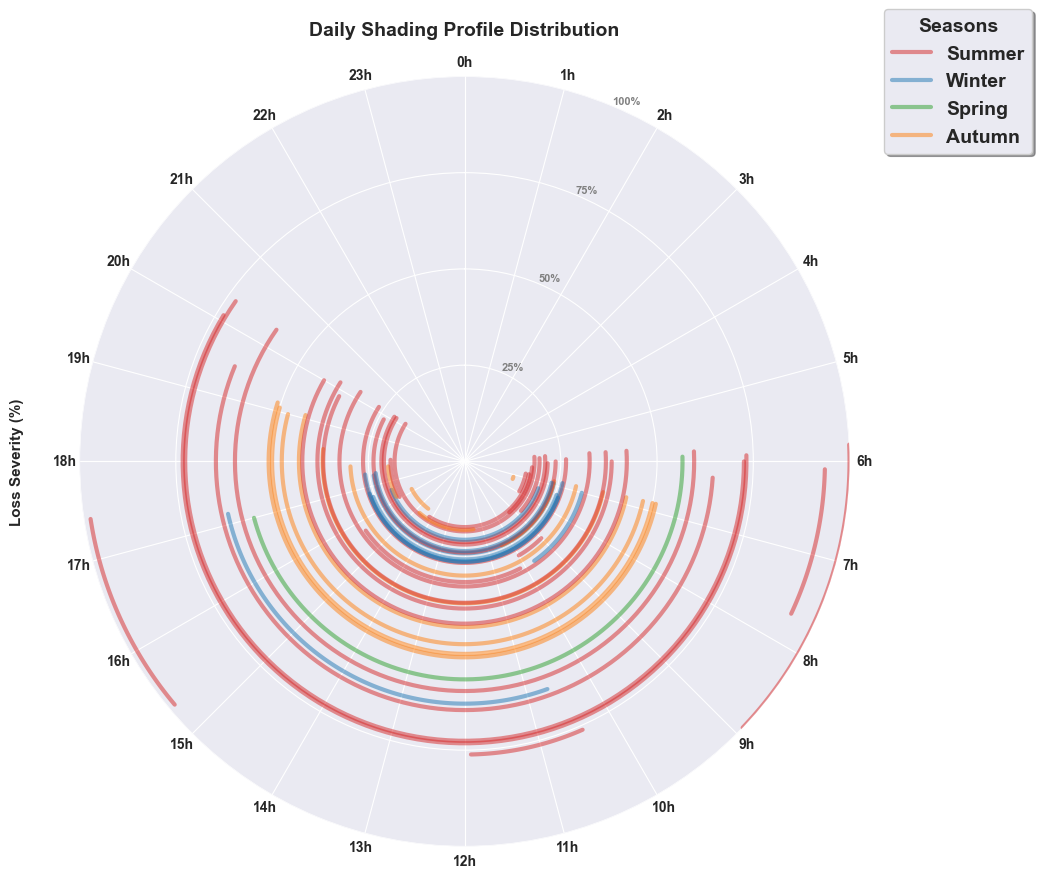

In [54]:
# ============================================================================
# HOURLY SHADING PROFILE (Circular 24h - English Version for Poster)
# ============================================================================
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='polar')

# Color mapping for seasons (English standard)
season_colors = {
    'Winter': '#1f77b4', # Blue
    'Spring': '#2ca02c', # Green
    'Summer': '#d62728', # Red
    'Autumn': '#ff7f0e'  # Orange
}

# Tracking labels to avoid duplicates in legend
added_labels = set()

for idx, row in df_shadow.iterrows():
    # Convert hours to radians (0-24h -> 0-2pi)
    theta_start = row['shadow_start_hour'] * (2 * np.pi / 24)
    theta_end = row['shadow_end_hour'] * (2 * np.pi / 24)
    
    # Create the arc (linspace ensures smooth lines)
    theta = np.linspace(theta_start, theta_end, 100)
    # The radius 'r' represents the loss percentage
    r = np.ones(100) * row['avg_loss_pct']
    
    season = row['season']
    label = season if season not in added_labels else "_nolegend_"
    added_labels.add(season)
    
    ax.plot(theta, r, alpha=0.5, linewidth=3, 
             color=season_colors.get(season, 'gray'), label=label)

# Polar Chart Formatting
ax.set_theta_zero_location('N')   # 00h (Midnight) at the Top
ax.set_theta_direction(-1)        # Clockwise progression
ax.set_xticks(np.linspace(0, 2*np.pi, 24, endpoint=False))
ax.set_xticklabels([f'{h}h' for h in range(24)], fontsize=10)

# Radial Axis (Loss Severity)
ax.set_ylim(0, 100)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], color='grey', fontsize=8)

# Title and Labels in English
ax.set_title('Daily Shading Profile Distribution', fontweight='bold', fontsize=14, pad=30)
ax.set_ylabel('Loss Severity (%)', labelpad=40, fontsize=11)

# Legend placement (Outside the plot area)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), 
           title="Seasons", frameon=True, shadow=True)

plt.savefig('hourly_shading_profile_en.png', dpi=300, bbox_inches='tight')